#   Intercomparison
Loading all the data up that were described in the previous notebook (`grid_runthrough.ipynb`).

To map the station to the nearest node.

Recapping on what I've got:
<!-- * `stations` - corrected station data, with the right projection -->
<!-- * `gdf_wm` - the observations -->
* `minifv0` - mesh of values at timestep and sigma layer 0. Contains `temp`
* `cmar` - the discrete mooring observations. Contains `temperature_degree_c`

Both of these are week-averaged products. When working with the time domain, you should refer to them by the week of the year.

Methods we want to try for mapping the `cmar` stations to the nearest mesh point:
* Nearest neighbor
* Nearest node
* Inverse distance
* Linear

Visualize what those look like.

With the stations aligned, get the CMAR temperatures at that section and subtract the model from them. These will be our `residuals`, which we'll want to visualize again.

Finally, if there are enough residual observations, try and interpolate between the points and plot it over the mesh. Kinda like how ODV uses DIVA plotting for interpolating the various bottle stops

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path

In [2]:
#   Some station names are just numbers. No worries with the DtypeWarning - should get read in as a string.
cmar_path = "/home/aaron-mau/Data/ohw/ohw26_model_downsampling_data/cmar_weekly_average_temperature.csv"
cmar = pd.read_csv(cmar_path)

/tmp/ipykernel_21481/2522185094.py:3: DtypeWarning: Columns (0: station) have mixed types. Specify dtype option on import or set low_memory=False.
  cmar = pd.read_csv(cmar_path)


In [3]:
# cmar[["temperature_degree_c", "station_depth_m", "iso_week", "year_week"]].describe() #   This doesn't run for some reason.
cmar.head()

,station,latitude,longitude,sensor_serial_number,timestamp_utc,sensor_depth_at_low_tide_m,temperature_degree_c,qc_flag_temperature_degree_c,station_depth_m,iso_year,iso_week,year_week,sensor_height_above_seafloor_m
0,1012,44.407102,-66.160532,10755237,2016-01-21T20:00:00Z,1.0,4.402,Not Evaluated,21,2016,3,2016 _ 3,20.0
1,1012,44.407102,-66.160532,10755237,2016-01-24T04:00:00Z,1.0,2.370,Pass,21,2016,3,2016 _ 3,20.0
2,1012,44.407102,-66.160532,10755237,2016-01-24T05:00:00Z,1.0,2.182,Pass,21,2016,3,2016 _ 3,20.0
3,1012,44.407102,-66.160532,10755237,2016-01-24T06:00:00Z,1.0,1.994,Pass,21,2016,3,2016 _ 3,20.0
4,1012,44.407102,-66.160532,10755237,2016-01-24T07:00:00Z,1.0,2.047,Pass,21,2016,3,2016 _ 3,20.0


In [4]:
full_path = Path("/home/aaron-mau/Code/ohw/2026/project/ohw26_model_downsampling/data/stmb_fvcom_weekly_avg_temp.nc")
minifv = xr.open_dataset(full_path, decode_times=False)
minifv0 = minifv[['temp','nv','h']].isel(time=0, siglay=0)

Ok - I want a verbose description of what minifv0 looks like. One of the goals Faizan and I had earlier was to explore what these meshes looked like

In [50]:
minifv0

<xarray.Dataset> Size: 379kB
Dimensions:  (node: 4247, three: 3, nele: 7697)
Coordinates:
    siglay   (node) float32 17kB -0.0025 -0.0025 -0.0025 ... -0.0025 -0.0025
    lon      (node) float64 34kB -66.22 -66.21 -66.22 ... -65.85 -65.85 -65.85
    lat      (node) float32 17kB 44.1 44.1 44.1 44.1 ... 44.57 44.57 44.57 44.57
    lonc     (nele) float64 62kB -66.21 -66.22 -66.21 ... -65.85 -65.85 -65.85
    latc     (nele) float32 31kB 44.1 44.1 44.1 44.11 ... 44.57 44.57 44.57
    time     int64 8B 0
Dimensions without coordinates: node, three, nele
Data variables:
    temp     (node) float32 17kB 5.714 5.543 5.906 6.139 ... 1.212 1.373 1.436
    nv       (three, nele) int64 185kB 1 1 2 3 3 3 ... 4242 4243 4247 4244 4245
    h        (node) float32 17kB 16.7 7.2 21.5 24.9 26.1 ... -2.9 -2.0 -2.3 -1.9

In [5]:
ds = minifv0   # or minifv, if you want to check before the isel

print("=== dims ===")
print(dict(ds.sizes))

print("\n=== every variable and coord ===")
for name in list(ds.coords) + list(ds.data_vars):
    v = ds[name]
    a = np.asarray(v.values)
    print(f"{name:>8} dims={v.dims} shape={a.shape} dtype={a.dtype}")

print("\n=== global attrs (projection info usually lives here) ===")
for k, val in minifv.attrs.items():
    print(f"  {k}: {val}")

print("\n=== coordinate ranges ===")
for name in ["lon", "lat", "lonc", "latc", "x", "y", "xc", "yc"]:
    if name in ds.variables:
        a = np.asarray(ds[name].values, dtype=float)
        print(f"{name:>5}: min={np.nanmin(a):>14.4f}  max={np.nanmax(a):>14.4f}  "
              f"n_nan={int(np.isnan(a).sum()):>5}  n_zero={int((a == 0).sum()):>5}  "
              f"units={ds[name].attrs.get('units', '?')}")

print("\n=== observation ranges ===")
print(f"  longitude: min={cmar['longitude'].min():.4f}  max={cmar['longitude'].max():.4f}  "
      f"n_nan={cmar['longitude'].isna().sum()}")
print(f"   latitude: min={cmar['latitude'].min():.4f}  max={cmar['latitude'].max():.4f}  "
      f"n_nan={cmar['latitude'].isna().sum()}")
print(f"  stations: {cmar['station'].nunique()}   rows: {len(cmar)}")

print("\n=== connectivity ===")
nv = np.asarray(ds["nv"].values)
print(f"  raw shape={nv.shape} dtype={nv.dtype} min={nv.min()} max={nv.max()}")
print(f"  n_node={ds.sizes['node']}  n_nele={ds.sizes['nele']}")
print(f"  looks {'1-based (Fortran)' if nv.min() == 1 else '0-based'}; "
      f"max index {'OK' if nv.max() <= ds.sizes['node'] else 'OUT OF RANGE'}")

print("\n=== temp ===")
t = np.asarray(ds["temp"].values, dtype=float)
print(f"  min={np.nanmin(t):.3f}  max={np.nanmax(t):.3f}  n_nan={int(np.isnan(t).sum())}")

=== dims ===
{'node': 4247, 'three': 3, 'nele': 7697}

=== every variable and coord ===
  siglay dims=('node',) shape=(4247,) dtype=float32
     lon dims=('node',) shape=(4247,) dtype=float32
     lat dims=('node',) shape=(4247,) dtype=float32
    lonc dims=('nele',) shape=(7697,) dtype=float32
    latc dims=('nele',) shape=(7697,) dtype=float32
    time dims=() shape=() dtype=int64
    temp dims=('node',) shape=(4247,) dtype=float32
      nv dims=('three', 'nele') shape=(3, 7697) dtype=int64
       h dims=('node',) shape=(4247,) dtype=float32

=== global attrs (projection info usually lives here) ===

=== coordinate ranges ===
  lon: min=      293.5005  max=      294.1540  n_nan=    0  n_zero=    0  units=degrees_east
  lat: min=       44.1000  max=       44.5996  n_nan=    0  n_zero=    0  units=degrees_north
 lonc: min=      293.5035  max=      294.1524  n_nan=    0  n_zero=    0  units=degrees_east
 latc: min=       44.1020  max=       44.5955  n_nan=    0  n_zero=    0  units=degr

Ok and now let's build the mesh step by step
* vertices
* edges
* temperature layer
* stations on top of the mesh

In [6]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

lon = np.asarray(ds["lon"].values, dtype=float)
lat = np.asarray(ds["lat"].values, dtype=float)

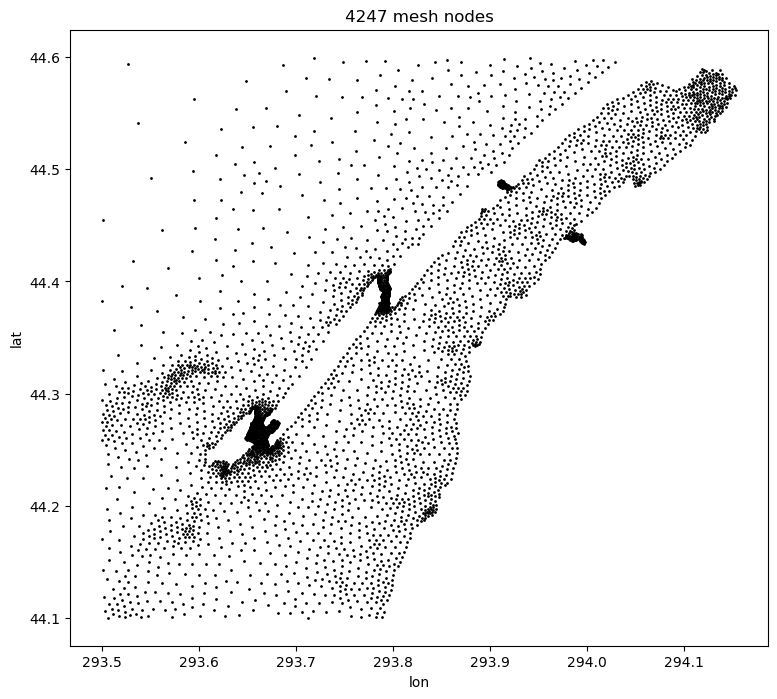

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(lon, lat, s=1, c="k")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title(f"{len(lon)} mesh nodes")
plt.show()

connectivity: (7697, 3) 0 4246 n_node = 4247


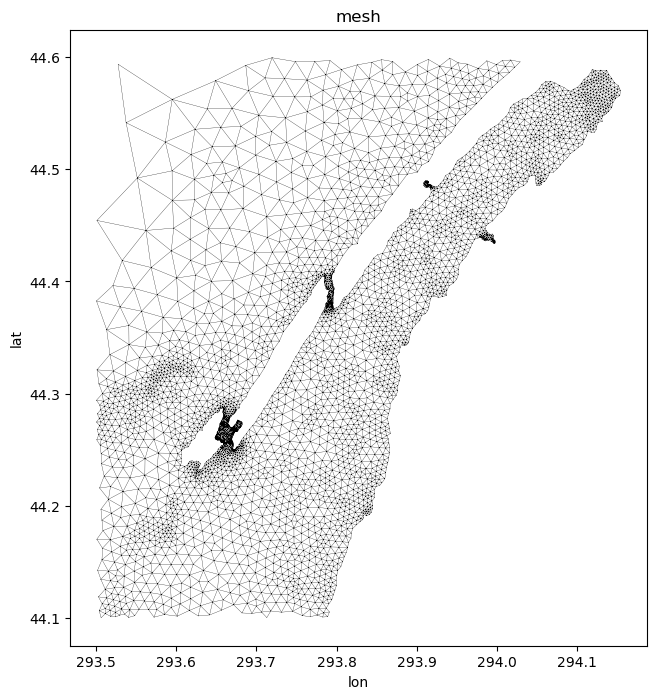

In [8]:
nv = np.asarray(ds["nv"].values)
if nv.shape[0] == 3:
    nv = nv.T                      # (three, nele) -> (nele, 3)
nv = nv.astype(int)
if nv.min() == 1:
    nv = nv - 1                    # Fortran -> 0-based
print("connectivity:", nv.shape, nv.min(), nv.max(), "n_node =", len(lon))

tri = mtri.Triangulation(lon, lat, nv)

fig, ax = plt.subplots(figsize=(9, 8))
ax.triplot(tri, color="k", lw=0.2)
ax.set_aspect(1 / np.cos(np.radians(np.nanmean(lat))))
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title("mesh")
plt.show()

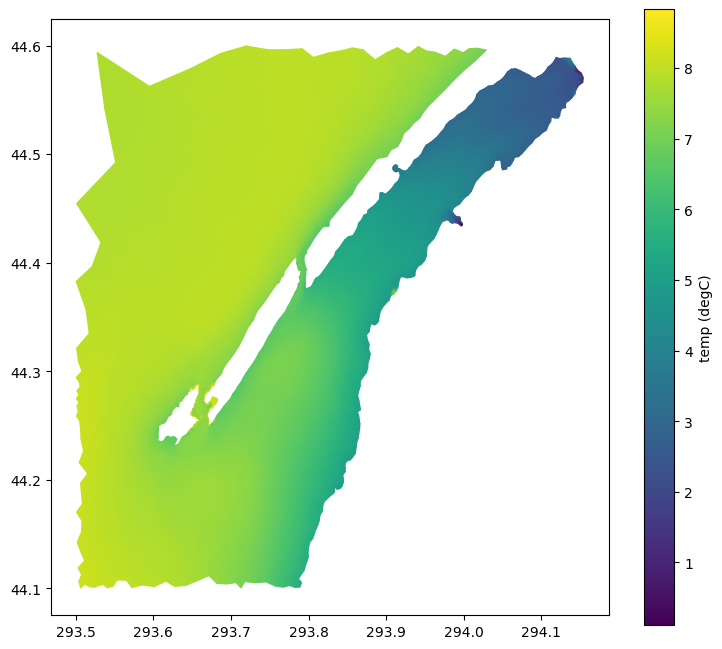

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
tpc = ax.tripcolor(tri, np.asarray(ds["temp"].values, dtype=float),
                   shading="gouraud", cmap="viridis")
plt.colorbar(tpc, ax=ax, label="temp (degC)")
ax.set_aspect(1 / np.cos(np.radians(np.nanmean(lat))))
plt.show()

In [10]:
ds.coords

Coordinates:
    siglay   (node) float32 17kB -0.0025 -0.0025 -0.0025 ... -0.0025 -0.0025
    lon      (node) float32 17kB 293.8 293.8 293.8 293.8 ... 294.2 294.2 294.2
    lat      (node) float32 17kB 44.1 44.1 44.1 44.1 ... 44.57 44.57 44.57 44.57
    lonc     (nele) float32 31kB 293.8 293.8 293.8 293.8 ... 294.2 294.2 294.2
    latc     (nele) float32 31kB 44.1 44.1 44.1 44.11 ... 44.57 44.57 44.57
    time     int64 8B 0

I don't know why Faizan's example
```python
# Extract lon/lat arrays from GeoPandas geometry
lons = xr.DataArray(gdf.geometry.x, dims="points")
lats = xr.DataArray(gdf.geometry.y, dims="points")

# Select nearest grid cells
station_elevation = bath_ds['elevation'].sel(lon=lons, lat=lats, method="nearest")
```
doesn't work.

In [ ]:
#   The fix from `grid_runthrough.ipynb`
minifv0 = minifv0.assign_coords(
    lon=("node", (((minifv0["lon"].values.astype(float) + 180) % 360) - 180)),
    lonc=("nele", (((minifv0["lonc"].values.astype(float) + 180) % 360) - 180)),
)

#   Sanity check to confirm that the transformed lat/lon of the mesh are larger than the observations
print("mesh lon:", float(minifv0.lon.min()), "to", float(minifv0.lon.max()))
print("mesh lat:", float(minifv0.lat.min()), "to", float(minifv0.lat.max()))
print("obs  lon:", cmar["longitude"].min(), "to", cmar["longitude"].max())
print("obs  lat:", cmar["latitude"].min(), "to", cmar["latitude"].max())

mesh lon: -66.49954223632812 to -65.84597778320312
mesh lat: 44.10002136230469 to 44.59959030151367
obs  lon: -66.224861 to -65.9322291333842
obs  lat: 44.32015 to 44.53912


The station overlap *doesn't* have to be Bokeh, since we've already done this before

Matplotlib might be preferable for something easier on the eyes with a grey mesh

13 stations


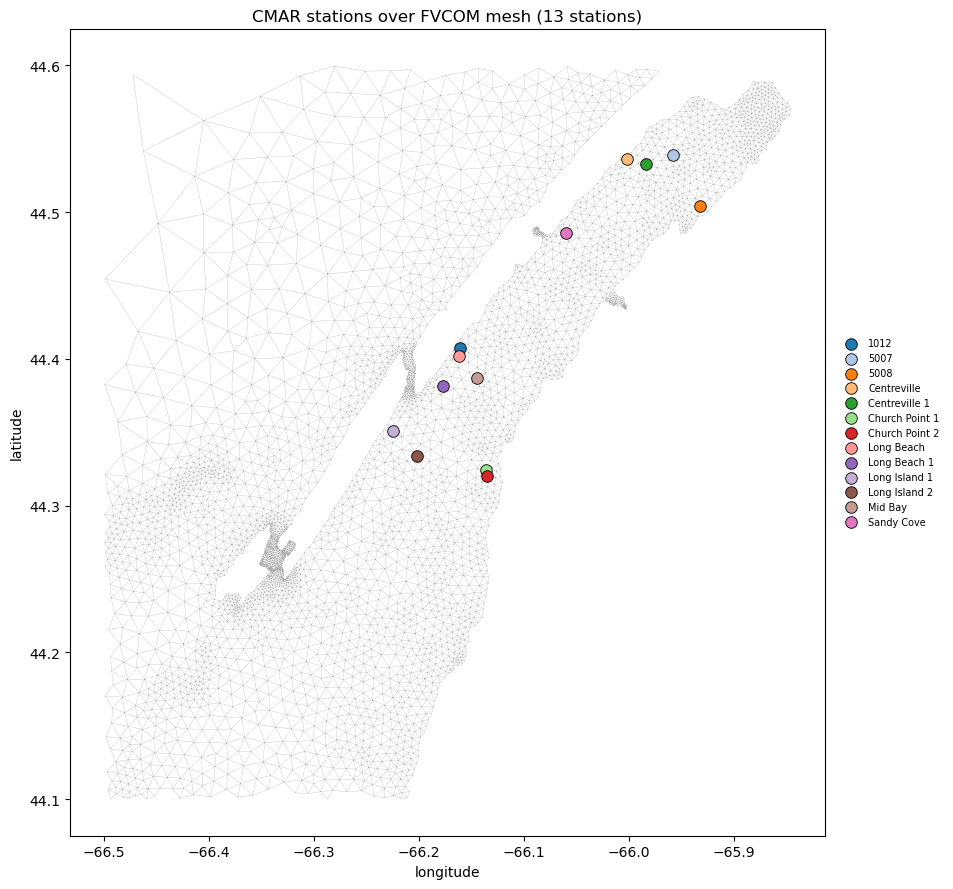

In [ ]:
lon = np.asarray(minifv0["lon"].values, dtype=float)
lat = np.asarray(minifv0["lat"].values, dtype=float)

nv = np.asarray(minifv0["nv"].values)
if nv.shape[0] == 3:
    nv = nv.T   # (three, nele) -> (nele, 3)
nv = nv.astype(int)
if nv.min() == 1:
    nv = nv - 1 # Fortran -> 0-based
tri = mtri.Triangulation(lon, lat, nv)

st = (cmar.assign(station=cmar["station"].astype(str))
          .groupby("station")
          .agg(lon=("longitude", "median"),
               lat=("latitude", "median"),
               n_obs=("temperature_degree_c", "size"))
          .reset_index())
print(f"{len(st)} stations")

pool = (list(plt.get_cmap("tab20").colors)
        + list(plt.get_cmap("tab20b").colors)
        + list(plt.get_cmap("tab20c").colors))
colors = [pool[i % len(pool)] for i in range(len(st))]

fig, ax = plt.subplots(figsize=(12, 9))
ax.triplot(tri, color="0.6", lw=0.2, alpha=0.8, zorder=1)

for (_, r), c in zip(st.iterrows(), colors):
    ax.scatter(r["lon"], r["lat"], s=70, color=c, edgecolor="k",
               lw=0.6, zorder=4, label=r["station"])

ax.set_aspect(1 / np.cos(np.radians(lat.mean())))
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"CMAR stations over FVCOM mesh ({len(st)} stations)")

if len(st) <= 30:
    ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, ncol=1 + len(st) // 20)    #   Warning: finicky
plt.tight_layout()
plt.show()

We want to work in meters - so we should be converting to [equirectangular projections](https://en.wikipedia.org/wiki/Equirectangular_projection).

This requires that we scale for lat/lon (recall OCE101 at UW - this is what they'd weed people out with on the exams)

In [ ]:
mlon = np.asarray(minifv0["lon"].values, dtype=float)
mlat = np.asarray(minifv0["lat"].values, dtype=float)

# scale longitude so a degree of lon is worth the same as a degree of lat at this latitude
coslat = np.cos(np.radians(mlat.mean()))

#  Number of stations and number of nodes
d2 = ((st["lon"].values[:, None] - mlon[None, :]) * coslat) ** 2 \
   + ((st["lat"].values[:, None] - mlat[None, :])) ** 2

st["node"] = d2.argmin(axis=1)
st["dist_km"] = np.sqrt(d2.min(axis=1)) * 111.195
#  "model_temp" is the FVCOM temperature corresponding to this location. The model is at the surface, so it should be cold if our time slice is in January.
# print(st["node"].T)
st["model_temp"] = np.asarray(minifv0["temp"].values, dtype=float)[st["node"]]

print(st.to_string(index=False))

0     2396
1     3833
2     3868
3     3779
4     3748
5     1793
6     1727
7     2301
8     2034
9     1601
10    1532
11    2295
12    3491
Name: node, dtype: int64
       station        lon       lat   n_obs  node  dist_km  model_temp
          1012 -66.160532 44.407102   19032  2396 0.061767    5.422169
          5007 -65.957980 44.539120   26781  3833 0.129532    3.003384
          5008 -65.932229 44.503857   27355  3868 0.276431    3.109595
   Centreville -66.001720 44.536239  148855  3779 0.246652    3.031803
 Centreville 1 -65.984040 44.532800  108592  3748 0.314850    3.205764
Church Point 1 -66.135683 44.324017   27189  1793 0.223379    5.561237
Church Point 2 -66.135067 44.320150   30349  1727 0.290156    5.637298
    Long Beach -66.161843 44.401851  380579  2301 0.119570    5.508881
  Long Beach 1 -66.177394 44.381841  280949  2034 0.156055    5.752007
 Long Island 1 -66.224861 44.350620  143435  1601 0.189521    6.659164
 Long Island 2 -66.201950 44.333633 1102153  1532 0

Of course there's a package that can do this...

In [ ]:
from scipy.interpolate import NearestNDInterpolator
f = NearestNDInterpolator(np.column_stack([mlon * coslat, mlat]),
                          np.asarray(minifv0["temp"].values, float))
print(f(st["lon"] * coslat, st["lat"])) #   Same as "model_temp" before.

[5.42216873 3.00338364 3.10959506 3.03180337 3.20576382 5.56123686
 5.63729811 5.50888062 5.75200653 6.65916395 6.80866337 5.52392626
 3.94825912]


In [ ]:
from scipy.spatial import cKDTree   #   This is the nearest neighbor assessor.

tree = cKDTree(np.column_stack([mlon * coslat, mlat]))
d, idx = tree.query(np.column_stack([st["lon"] * coslat, st["lat"]]), k=1)  #   distance, index
st["node"], st["dist_km"] = idx, d * 111.195

In [15]:
pts = xr.DataArray(st["node"].values, dims="station",
                   coords={"station": st["station"].values})
station_temp = minifv0["temp"].isel(node=pts)
station_h    = minifv0["h"].isel(node=pts)

In [16]:
print(st[["station", "node", "dist_km", "model_temp"]].sort_values("dist_km", ascending=False))
print("\nnodes claimed by >1 station:")
print(st.groupby("node").size().pipe(lambda s: s[s > 1]))

           station  node   dist_km  model_temp
10   Long Island 2  1532  0.386604    6.808663
4    Centreville 1  3748  0.314850    3.205764
6   Church Point 2  1727  0.290156    5.637298
2             5008  3868  0.276431    3.109595
12      Sandy Cove  3491  0.268613    3.948259
3      Centreville  3779  0.246652    3.031803
11         Mid Bay  2295  0.232745    5.523926
5   Church Point 1  1793  0.223379    5.561237
9    Long Island 1  1601  0.189521    6.659164
8     Long Beach 1  2034  0.156055    5.752007
1             5007  3833  0.129532    3.003384
7       Long Beach  2301  0.119570    5.508881
0             1012  2396  0.061767    5.422169

nodes claimed by >1 station:
Series([], dtype: int64)


Redeclare if the notebook lapses...

In [17]:
import numpy as np
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import (ColumnDataSource, HoverTool, CustomJS, Range1d)
from bokeh.palettes import Category20, Category20b, Category20c

output_notebook()

R = 6371.0088

# ---------- mesh ----------
mlon = np.asarray(minifv0["lon"].values, dtype=float)
mlat = np.asarray(minifv0["lat"].values, dtype=float)
mtemp = np.asarray(minifv0["temp"].values, dtype=float)

nv = np.asarray(minifv0["nv"].values)
if nv.shape[0] == 3:
    nv = nv.T
nv = nv.astype(int)
if nv.min() == 1:
    nv = nv - 1

# local equirectangular projection, km
lon0, lat0 = mlon.mean(), mlat.mean()
kx = np.radians(1.0) * R * np.cos(np.radians(lat0))   # km per degree lon
ky = np.radians(1.0) * R                              # km per degree lat
to_x = lambda lo: (np.asarray(lo, dtype=float) - lon0) * kx
to_y = lambda la: (np.asarray(la, dtype=float) - lat0) * ky

nx, ny = to_x(mlon), to_y(mlat)

# closed triangle outlines
tri_x = np.column_stack([nx[nv[:, 0]], nx[nv[:, 1]], nx[nv[:, 2]], nx[nv[:, 0]]]).tolist()
tri_y = np.column_stack([ny[nv[:, 0]], ny[nv[:, 1]], ny[nv[:, 2]], ny[nv[:, 0]]]).tolist()
mesh_src = ColumnDataSource(dict(xs=tri_x, ys=tri_y))

# ---------- stations ----------
pool = list(Category20[20]) + list(Category20b[20]) + list(Category20c[20])
node_idx = st["node"].values.astype(int)

stn_src = ColumnDataSource(dict(
    x=to_x(st["lon"].values),
    y=to_y(st["lat"].values),
    lon=st["lon"].values,
    lat=st["lat"].values,
    station=st["station"].astype(str).values,
    node=node_idx,
    dist_km=st["dist_km"].values,
    model_temp=st["model_temp"].values,
    n_obs=st["n_obs"].values if "n_obs" in st else np.zeros(len(st), int),
    color=[pool[i % len(pool)] for i in range(len(st))],
))

# the node each station was mapped to
node_src = ColumnDataSource(dict(
    x=nx[node_idx], y=ny[node_idx],
    lon=mlon[node_idx], lat=mlat[node_idx],
    node=node_idx, temp=mtemp[node_idx],
    color=[pool[i % len(pool)] for i in range(len(st))],
))

# connector: station -> its node
link_src = ColumnDataSource(dict(
    x0=to_x(st["lon"].values), y0=to_y(st["lat"].values),
    x1=nx[node_idx], y1=ny[node_idx],
))

# ---------- figure ----------
pad = 1.0
p = figure(width=950, height=800, match_aspect=True,
           x_axis_label="east-west (km)", y_axis_label="north-south (km)",
           title="CMAR stations mapped to nearest FVCOM node",
           tools="pan,wheel_zoom,box_zoom,reset,save",
           active_scroll="wheel_zoom")
p.x_range = Range1d(nx.min() - pad, nx.max() + pad)
p.y_range = Range1d(ny.min() - pad, ny.max() + pad)

p.multi_line("xs", "ys", source=mesh_src, line_color="#999999",
             line_width=0.4, line_alpha=0.55, level="underlay")
p.scatter(nx, ny, size=1.5, color="#bbbbbb", level="underlay")

p.segment("x0", "y0", "x1", "y1", source=link_src,
          line_color="#d62728", line_width=1.5)

node_r = p.scatter("x", "y", source=node_src, marker="square", size=9,
                   fill_color="color", line_color="black", line_width=1.2)
stn_r = p.scatter("x", "y", source=stn_src, marker="circle", size=13,
                  fill_color="color", line_color="black", line_width=1.0)

p.add_tools(HoverTool(renderers=[stn_r], tooltips=[
    ("station", "@station"), ("node", "@node"),
    ("dist", "@dist_km{0.000} km"),
    ("obs lon/lat", "@lon{0.0000}, @lat{0.0000}"),
    ("model temp", "@model_temp{0.00} degC"),
    ("n obs", "@n_obs"),
]))
p.add_tools(HoverTool(renderers=[node_r], tooltips=[
    ("mapped node", "@node"),
    ("node lon/lat", "@lon{0.0000}, @lat{0.0000}"),
    ("temp", "@temp{0.00} degC"),
]))

# ---------- scale bar, bottom right, snaps to a round number on zoom ----------
bar_src = ColumnDataSource(dict(x0=[0], x1=[0], y0=[0], y1=[0]))
tick_src = ColumnDataSource(dict(xs=[[0, 0]], ys=[[0, 0]]))
lbl_src = ColumnDataSource(dict(x=[0], y=[0], text=[""]))

p.segment("x0", "y0", "x1", "y1", source=bar_src, line_color="black", line_width=3)
p.multi_line("xs", "ys", source=tick_src, line_color="black", line_width=3)
p.text("x", "y", text="text", source=lbl_src, text_font_size="11px",
       text_align="center", text_baseline="bottom", text_color="black")

cb = CustomJS(args=dict(xr=p.x_range, yr=p.y_range, bar=bar_src,
                        tick=tick_src, lbl=lbl_src), code="""
    const spanx = xr.end - xr.start, spany = yr.end - yr.start;
    if (!isFinite(spanx) || spanx <= 0) return;

    const target = spanx * 0.2;
    const pw = Math.pow(10, Math.floor(Math.log10(target)));
    let L = [1, 2, 5, 10].map(m => m * pw)
              .reduce((a, b) => Math.abs(b - target) < Math.abs(a - target) ? b : a);

    const xe = xr.end - spanx * 0.06;         // right edge of bar
    const xs_ = xe - L;
    const yb = yr.start + spany * 0.07;
    const t = spany * 0.012;                  // end-tick half height

    bar.data = {x0: [xs_], x1: [xe], y0: [yb], y1: [yb]};
    tick.data = {xs: [[xs_, xs_], [xe, xe]], ys: [[yb - t, yb + t], [yb - t, yb + t]]};
    lbl.data = {x: [(xs_ + xe) / 2], y: [yb + t * 1.6],
                text: [L >= 1 ? L + " km" : Math.round(L * 1000) + " m"]};
""")
for r in (p.x_range, p.y_range):
    r.js_on_change("start", cb)
    r.js_on_change("end", cb)

show(p)

Loading BokehJS ...

Awesome, we can confirm that our `dist_km` values match what we're physically able to measure on the plot when zoomed in.

The next step will be to start looking at it all vs time. We've got a lot of binned weeks that should be easy to compare.

In [18]:
minifv

<xarray.Dataset> Size: 177MB
Dimensions:        (time: 53, nele: 7697, node: 4247, siglay: 20, siglev: 21,
                    three: 3, maxnode: 10, maxelem: 8, four: 4)
Coordinates:
  * time           (time) int64 424B 0 7 14 21 28 35 ... 329 336 343 350 357 364
    lonc           (nele) float32 31kB 293.8 293.8 293.8 ... 294.2 294.2 294.2
    latc           (nele) float32 31kB 44.1 44.1 44.1 ... 44.57 44.57 44.57
    lon            (node) float32 17kB 293.8 293.8 293.8 ... 294.2 294.2 294.2
    lat            (node) float32 17kB 44.1 44.1 44.1 44.1 ... 44.57 44.57 44.57
    siglay         (siglay, node) float32 340kB ...
    siglev         (siglev, node) float32 357kB ...
Dimensions without coordinates: nele, node, three, maxnode, maxelem, four
Data variables: (12/27)
    nprocs         (time) float64 424B ...
    partition      (time, nele) int32 2MB ...
    x              (time, node) float32 900kB ...
    y              (time, node) float32 900kB ...
    xc             (time, nele) float32 2MB ...
    yc             (time, nele) float32 2MB ...
    ...             ...
    awx            (time, three, nele) float32 5MB ...
    awy            (time, three, nele) float32 5MB ...
    art2           (time, node) float32 900kB ...
    art1           (time, node) float32 900kB ...
    omega          (time, siglev, node) float32 19MB ...
    temp           (time, siglay, node) float32 18MB ...

In [19]:
cmar[cmar["iso_week"]==50]

,station,latitude,longitude,sensor_serial_number,timestamp_utc,sensor_depth_at_low_tide_m,temperature_degree_c,qc_flag_temperature_degree_c,station_depth_m,iso_year,iso_week,year_week,sensor_height_above_seafloor_m
200364,Centreville,44.536239,-66.00172,671044,2021-12-13T00:06:00Z,3.5,6.92,Pass,4,2021,50,2021 _ 50,0.5
200365,Centreville,44.536239,-66.00172,671044,2021-12-13T00:16:00Z,3.5,6.74,Pass,4,2021,50,2021 _ 50,0.5
200366,Centreville,44.536239,-66.00172,671044,2021-12-13T00:26:00Z,3.5,6.60,Pass,4,2021,50,2021 _ 50,0.5
200367,Centreville,44.536239,-66.00172,671044,2021-12-13T00:36:00Z,3.5,6.48,Pass,4,2021,50,2021 _ 50,0.5
200368,Centreville,44.536239,-66.00172,671044,2021-12-13T00:46:00Z,3.5,6.40,Pass,4,2021,50,2021 _ 50,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328922,Sandy Cove,44.485667,-66.05965,548588,2024-12-15T19:00:00Z,18.0,4.60,Pass,21,2024,50,2024 _ 50,3.0
3328923,Sandy Cove,44.485667,-66.05965,548588,2024-12-15T20:00:00Z,18.0,4.40,Pass,21,2024,50,2024 _ 50,3.0
3328924,Sandy Cove,44.485667,-66.05965,548588,2024-12-15T21:00:00Z,18.0,4.10,Pass,21,2024,50,2024 _ 50,3.0
3328925,Sandy Cove,44.485667,-66.05965,548588,2024-12-15T22:00:00Z,18.0,4.20,Pass,21,2024,50,2024 _ 50,3.0


Ok, so some stations will drop off periodically. Note that this is also for a series of observations at different depths.

In [20]:
MONDAY_EPOCH = pd.Timestamp("1970-01-05")

def iso_week_start(iso_year, iso_week):
    """(2017, 5) -> Timestamp of that ISO week's Monday."""
    y = pd.Series(iso_year).astype(int).astype(str)
    w = pd.Series(iso_week).astype(int).astype(str).str.zfill(2)
    return pd.to_datetime(y + "-W" + w + "-1", format="%G-W%V-%u")

#   I think I remember Danielle and Rachel talking about using the low tide depths - they have a tech that's looking up equivalents
#   (probably default to that rather than some other depth)
def weekly_coverage(cmar, depth_mode="shallowest", target_depth_m=None, depth_tol_m=0.5,
                    qc_keep=("Pass", "Not Evaluated"), min_samples=24,
                    temp_col="temperature_degree_c",
                    depth_col="sensor_depth_at_low_tide_m",
                    qc_col="qc_flag_temperature_degree_c", verbose=True):
    """One row per (station, depth, ISO week) that actually has data.

    depth_mode:
      'shallowest' - only the shallowest sensor at each station (one track per station)
      'all'        - every distinct sensor depth separately (one track per station x depth)
      'target'     - sensors within depth_tol_m of target_depth_m
    """
    df = cmar.copy()
    df["station"] = df["station"].astype(str)
    n0 = len(df)

    if qc_keep is not None and qc_col in df.columns:
        df = df[df[qc_col].isin(qc_keep)]
    df = df.dropna(subset=[temp_col, depth_col])

    if depth_mode == "shallowest":
        df = df[df[depth_col] <= df.groupby("station")[depth_col].transform("min") + depth_tol_m]
    elif depth_mode == "target":
        if target_depth_m is None:
            raise ValueError("depth_mode='target' needs target_depth_m")
        df = df[(df[depth_col] - target_depth_m).abs() <= depth_tol_m]
    elif depth_mode != "all":
        raise ValueError("depth_mode must be 'shallowest', 'all', or 'target'")

    if df.empty:
        raise ValueError("no rows left after QC/depth filtering")

    df["depth_m"] = df[depth_col].round(1)
    cov = (df.groupby(["station", "depth_m", "iso_year", "iso_week"])
             .agg(n_samples=(temp_col, "size"),
                  mean_temp=(temp_col, "mean"),
                  sd_temp=(temp_col, "std"),
                  lon=("longitude", "median"),
                  lat=("latitude", "median"))
             .reset_index())

    n_pre = len(cov)
    cov = cov[cov["n_samples"] >= min_samples].copy()
    cov["week_start"] = iso_week_start(cov["iso_year"], cov["iso_week"])
    cov["week_index"] = ((cov["week_start"] - MONDAY_EPOCH).dt.days // 7).astype(int)
    cov["track"] = (cov["station"] if depth_mode == "shallowest"
                    else cov["station"] + " @ " + cov["depth_m"].astype(str) + " m")

    if verbose:
        print(f"{n0} raw rows -> {len(df)} after QC/depth -> {n_pre} station-weeks "
              f"-> {len(cov)} with >= {min_samples} samples")
        print(f"{cov['track'].nunique()} tracks, "
              f"{cov['week_start'].min().date()} to {cov['week_start'].max().date()}")
    return cov.sort_values(["track", "week_index"]).reset_index(drop=True)

In [21]:
def coverage_runs(cov, gap_tolerance_weeks=0):
    """Merge consecutive covered weeks into contiguous bars.
    gap_tolerance_weeks=1 bridges single missing weeks instead of splitting the bar."""
    rows = []
    for track, sub in cov.groupby("track", sort=False):
        sub = sub.sort_values("week_index")
        wk = sub["week_index"].values
        brk = np.where(np.diff(wk) > 1 + gap_tolerance_weeks)[0]
        starts, ends = np.r_[0, brk + 1], np.r_[brk, len(wk) - 1]
        for s, e in zip(starts, ends):
            seg = sub.iloc[s:e + 1]
            rows.append({
                "track": track,
                "station": seg["station"].iloc[0],
                "depth_m": seg["depth_m"].iloc[0],
                "start_week": seg["week_start"].iloc[0],
                "end_week": seg["week_start"].iloc[-1] + pd.Timedelta(days=7),
                "n_weeks_spanned": int(wk[e] - wk[s] + 1),
                "n_weeks_with_data": len(seg),
                "n_samples": int(seg["n_samples"].sum()),
                "mean_temp": seg["mean_temp"].mean(),
            })
    return pd.DataFrame(rows).sort_values(["start_week", "track"]).reset_index(drop=True)


def coverage_summary(cov, verbose=True):
    s = (cov.groupby("track")
            .agg(station=("station", "first"), depth_m=("depth_m", "first"),
                 n_weeks=("week_index", "nunique"),
                 first_week=("week_start", "min"), last_week=("week_start", "max"),
                 n_samples=("n_samples", "sum"))
            .reset_index())
    s["span_weeks"] = ((s["last_week"] - s["first_week"]).dt.days / 7).astype(int) + 1
    s["completeness"] = (s["n_weeks"] / s["span_weeks"]).round(3)
    if verbose:
        print(s.sort_values("n_weeks", ascending=False).to_string(index=False))
    return s

In [22]:
import matplotlib.dates as mdates

def plot_coverage(cov, runs=None, gap_tolerance_weeks=0, sort_by="first",
                  shade_gaps=True, figsize=None):
    """Horizontal bars per track, one blob per continuous stretch of weekly data.

    sort_by: 'first' (by start date), 'coverage' (fewest weeks at the bottom), or 'name'.
    shade_gaps hatches the missing weeks bridged by gap_tolerance_weeks."""
    runs = coverage_runs(cov, gap_tolerance_weeks) if runs is None else runs

    if sort_by == "first":
        order = runs.groupby("track")["start_week"].min().sort_values().index
    elif sort_by == "coverage":
        order = cov.groupby("track")["week_index"].nunique().sort_values().index
    else:
        order = sorted(cov["track"].unique())
    order = list(order)
    ypos = {t: i for i, t in enumerate(order)}

    pool = (list(plt.get_cmap("tab20").colors) + list(plt.get_cmap("tab20b").colors)
            + list(plt.get_cmap("tab20c").colors))
    colors = {t: pool[i % len(pool)] for i, t in enumerate(order)}

    fig, ax = plt.subplots(figsize=figsize or (14, max(4, 0.32 * len(order) + 2)))

    for track, sub in runs.groupby("track"):
        bars = [(mdates.date2num(r["start_week"]),
                 mdates.date2num(r["end_week"]) - mdates.date2num(r["start_week"]))
                for _, r in sub.iterrows()]
        ax.broken_barh(bars, (ypos[track] - 0.38, 0.76), facecolors=colors[track],
                       edgecolor="black", linewidth=0.4, zorder=3)

    if shade_gaps:
        for track, sub in cov.groupby("track"):
            have = set(sub["week_index"])
            for w in range(min(have), max(have) + 1):
                if w not in have:
                    d0 = mdates.date2num(MONDAY_EPOCH + pd.Timedelta(weeks=w))
                    ax.broken_barh([(d0, 7)], (ypos[track] - 0.38, 0.76),
                                   facecolors="none", hatch="///",
                                   edgecolor="red", linewidth=0.0, zorder=4)

    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=8)
    ax.set_ylim(-0.7, len(order) - 0.3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) #   Plotting every month led to too many ticks
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(axis="x", ls=":", alpha=0.4, zorder=0)
    ax.set_xlabel("ISO week")
    ax.set_ylabel("station" if "@" not in order[0] else "station @ depth")
    ax.set_title(f"CMAR coverage: {len(order)} tracks, "
                 f"{cov['week_index'].nunique()} distinct weeks")
    fig.tight_layout()
    return fig, ax

3332998 raw rows -> 614817 after QC/depth -> 927 station-weeks -> 926 with >= 24 samples
13 tracks, 2016-01-18 to 2025-06-02
         track        station  depth_m  n_weeks first_week  last_week  n_samples  span_weeks  completeness
 Long Island 2  Long Island 2      2.0      195 2020-07-13 2025-06-02     128001         256         0.762
    Sandy Cove     Sandy Cove      2.0      175 2020-07-13 2024-06-03     113692         204         0.858
   Centreville    Centreville      3.5      149 2021-08-02 2024-06-03     139674         149         1.000
    Long Beach     Long Beach      2.0      100 2020-07-13 2022-06-06      65474         100         1.000
  Long Beach 1   Long Beach 1      2.0       75 2022-08-22 2024-06-03      48775          94         0.798
 Centreville 1  Centreville 1      2.0       42 2019-01-14 2019-10-28      26034          42         1.000
 Long Island 1  Long Island 1      2.0       40 2019-01-14 2020-11-23      24482          98         0.408
          1012     

(<Figure size 1400x616 with 1 Axes>,
 <Axes: title={'center': 'CMAR coverage: 13 tracks, 342 distinct weeks'}, xlabel='ISO week', ylabel='station'>)

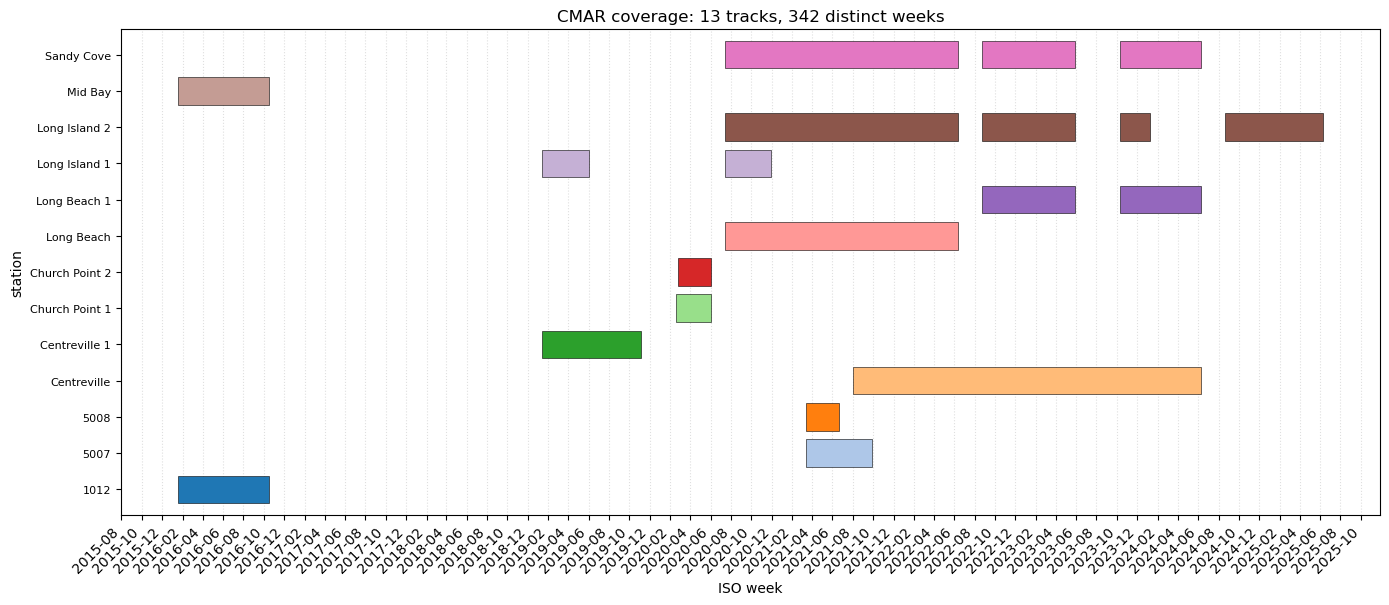

In [54]:
cov = weekly_coverage(cmar, depth_mode="shallowest", min_samples=24)    #   We want the shallowest values in here
coverage_summary(cov)
plot_coverage(cov, sort_by="name", shade_gaps=False)

Cool, I've got a good plot now, but I don't know where it holds.

Note: This is very comparable to what Danielle is reporting. It seems like my results are shorter than hers, but I'm only using the shallowest depth at each point. When I plot "all", rather than "shallowest", I get a chart that's harder to read.

Looks like at most we have 5 stations active at a given time. When is that?

In [24]:
def best_weeks(cov):
    """Find the max number of simultaneously active stations and the week ranges where it holds."""
    w = (cov.groupby(["week_index", "week_start"])["station"]
            .agg(n="nunique", stations=lambda s: sorted(set(s)))
            .reset_index()
            .sort_values("week_index"))

    peak = w["n"].max()
    hit = w[w["n"] == peak]

    idx = hit["week_index"].values
    brk = np.where(np.diff(idx) > 1)[0]
    starts, ends = np.r_[0, brk + 1], np.r_[brk, len(idx) - 1]

    print(f"max {peak} stations active, in {len(hit)} week(s):")
    for s, e in zip(starts, ends):
        seg = hit.iloc[s:e + 1]
        a = seg["week_start"].iloc[0]
        b = seg["week_start"].iloc[-1] + pd.Timedelta(days=7)
        common = sorted(set.intersection(*[set(x) for x in seg["stations"]]))
        print(f"  {a.date()} to {b.date()}  ({len(seg)} wk)  {', '.join(common)}")

    return w
w = best_weeks(cov)

max 5 stations active, in 22 week(s):
  2021-03-15 to 2021-06-21  (14 wk)  5007, 5008, Long Beach, Long Island 2, Sandy Cove
  2021-08-02 to 2021-09-27  (8 wk)  5007, Centreville, Long Beach, Long Island 2, Sandy Cove


Okay, so we've got a good chunk of 2021's spring and fall to work with.

At this point we've got two things: The timescales of the best coverage of our stations, and the map to which exact node we should be pulling from to take the offset.

We were originally going to try and extend with another subset of observations (CMAR-H), but that idea kinda fell apart.

So what we'll do is we'll "assume" that the model year is irrelevant. I'll take a spring/fall slice of the model, at the shallowest depth, and compare that to what the station was reading.

This has no scientific merit since it isn't a climatology, but it does lay the groundwork on Rachel doing some modeling on her own for the timeframes where the mooring observation coverage of St. Mary's Bay is highest.

Keep in mind: These weeks are indexed differently. There is no week 0 in `cmar` but `minifv` begins at 0. They're for different years. I don't *think* they're leap years, but there is also some noise at the end of the year related to an incomplete final week (thanks, ancient Roman emperors for ruining what the Greeks pieced together through logic).

In [25]:
def model_weeks_in_window(ds, start="03-15", end="06-21", min_overlap_days=1, verbose=True):
    """Model time bins overlapping the given month-day window. Year is ignored.
    Each bin gets the ISO week of its midpoint, which is the week it mostly covers."""
    units = ds["time"].attrs.get("units", "days since 2016-12-31 00:00:00")
    origin = pd.Timestamp(units.split("since")[-1].strip())
    days = np.asarray(ds["time"].values, dtype=float)

    bin_start = pd.DatetimeIndex(origin + pd.to_timedelta(days, unit="D"))
    bin_end = bin_start + pd.Timedelta(days=7)
    mid = bin_start + pd.Timedelta(days=3, hours=12)
    iso = mid.isocalendar()

    tbl = pd.DataFrame({
        "time_index": np.arange(len(days)),
        "time_value": days.astype(int),
        "bin_start": bin_start,
        "bin_end": bin_end,
        "iso_week": iso["week"].values,
    })

    # window anchored to the year each bin's midpoint falls in
    yr = mid.year
    win_lo = pd.to_datetime([f"{y}-{start}" for y in yr])
    win_hi = pd.to_datetime([f"{y}-{end}" for y in yr]) + pd.Timedelta(days=1)

    lo = np.maximum(tbl["bin_start"].values, win_lo.values)
    hi = np.minimum(tbl["bin_end"].values, win_hi.values)
    tbl["overlap_days"] = np.maximum((hi - lo) / np.timedelta64(1, "D"), 0.0)

    sel = tbl[tbl["overlap_days"] >= min_overlap_days].reset_index(drop=True)
    if verbose:
        print(f"{len(sel)} model weeks cover {start} to {end}: "
              f"ISO weeks {sel['iso_week'].min()}-{sel['iso_week'].max()}, "
              f"{sel['bin_start'].min().date()} to {sel['bin_end'].max().date()}")
    return sel

In [26]:
def obs_shallowest_by_week(cmar, iso_weeks=None, pool_years=True, min_samples=1,
                           qc_keep=("Pass", "Not Evaluated"), depth_tol_m=0.5, verbose=True):
    """Weekly mean temperature at each station's shallowest sensor.
    pool_years=True averages across years, matching the 'year is irrelevant' assumption."""
    df = cmar.copy()
    df["station"] = df["station"].astype(str)

    if qc_keep is not None:
        df = df[df["qc_flag_temperature_degree_c"].isin(qc_keep)]
    df = df.dropna(subset=["temperature_degree_c", "sensor_depth_at_low_tide_m"])

    shallow = df.groupby("station")["sensor_depth_at_low_tide_m"].transform("min")
    df = df[df["sensor_depth_at_low_tide_m"] <= shallow + depth_tol_m]

    if iso_weeks is not None:
        df = df[df["iso_week"].isin(list(iso_weeks))]
    if df.empty:
        raise ValueError("no observations in those ISO weeks after filtering")

    keys = ["station", "iso_week"] if pool_years else ["station", "iso_year", "iso_week"]
    obs = (df.groupby(keys)
             .agg(obs_temp=("temperature_degree_c", "mean"),
                  obs_sd=("temperature_degree_c", "std"),
                  n_samples=("temperature_degree_c", "size"),
                  n_years=("iso_year", "nunique"),
                  obs_depth_m=("sensor_depth_at_low_tide_m", "min"))
             .reset_index())
    obs = obs[obs["n_samples"] >= min_samples].reset_index(drop=True)

    if verbose:
        print(f"{len(obs)} station-weeks, {obs['station'].nunique()} stations, "
              f"ISO weeks {obs['iso_week'].min()}-{obs['iso_week'].max()}")
        if pool_years:
            print(f"years pooled per week: {obs['n_years'].min()}-{obs['n_years'].max()}")
    return obs

In [27]:
def model_temp_at_stations(ds, mweeks, st, siglay=0, temp_var="temp"):
    """Long table of model temperature at each station's node, one row per (station, week)."""
    nodes = st["node"].values.astype(int)
    sub = ds[temp_var].isel(siglay=siglay, time=mweeks["time_index"].values)
    vals = np.asarray(sub.values, dtype=float)[:, nodes]      # (n_weeks, n_stations)

    return pd.DataFrame({
        "station": np.tile(st["station"].astype(str).values, len(mweeks)),
        "node": np.tile(nodes, len(mweeks)),
        "iso_week": np.repeat(mweeks["iso_week"].values, len(st)),
        "time_index": np.repeat(mweeks["time_index"].values, len(st)),
        "bin_start": np.repeat(mweeks["bin_start"].values, len(st)),
        "model_temp": vals.ravel(),
        "lon": np.tile(st["lon"].values, len(mweeks)),
        "lat": np.tile(st["lat"].values, len(mweeks)),
    })

In [41]:
def weekly_residuals(ds, cmar, st, start="03-15", end="06-21", siglay=0,
                     pool_years=True, min_samples=1, min_overlap_days=1, verbose=True):
    """residual = observation - model, per station per week, over the chosen window.
    Stations with no data in a week come back as NaN."""
    mweeks = model_weeks_in_window(ds, start, end, min_overlap_days, verbose=verbose)
    obs = obs_shallowest_by_week(cmar, mweeks["iso_week"], pool_years,
                                 min_samples, verbose=verbose)
    mod = model_temp_at_stations(ds, mweeks, st, siglay=siglay)

    # force the join keys to match — isocalendar() returns UInt32, cmar is int64
    obs["iso_week"] = obs["iso_week"].astype(int)
    mod["iso_week"] = mod["iso_week"].astype(int)
    obs["station"] = obs["station"].astype(str)
    mod["station"] = mod["station"].astype(str)

    res = mod.merge(obs, on=["station", "iso_week"], how="left")
    res["residual"] = res["obs_temp"] - res["model_temp"]

    if verbose:
        n_ok = int(res["residual"].notna().sum())
        print(f"\n{len(res)} station-weeks, {n_ok} with observations "
              f"({n_ok / len(res):.0%} filled)")
        if n_ok:
            print(f"residual: mean {res['residual'].mean():.3f}, "
                  f"sd {res['residual'].std():.3f}, "
                  f"range {res['residual'].min():.3f} to {res['residual'].max():.3f} degC")
        else:
            print("WARNING: no observations matched any model week — check the merge keys")
    return res.sort_values(["iso_week", "station"]).reset_index(drop=True)

In [29]:
def residuals_wide(res, value="residual"):
    """(week x station) matrix. Handy for a heatmap or a quick look at what's missing."""
    return res.pivot_table(index="iso_week", columns="station", values=value)


def residuals_on_mesh(res, ds, value="residual"):
    """(week, node) array aligned to the mesh, NaN everywhere without a station.
    Index a row and hand it straight to tripcolor, or use .sel(iso_week=...)."""
    weeks = np.sort(res["iso_week"].unique())
    arr = np.full((len(weeks), ds.sizes["node"]), np.nan)
    wpos = {w: i for i, w in enumerate(weeks)}
    for _, r in res.dropna(subset=[value]).iterrows():
        arr[wpos[r["iso_week"]], int(r["node"])] = r[value]

    return xr.DataArray(arr, dims=("iso_week", "node"),
                        coords={"iso_week": weeks, "node": np.arange(ds.sizes["node"])},
                        name=value, attrs={"units": "degrees_C",
                                           "long_name": "observation minus model"})

In [42]:
res = weekly_residuals(minifv, cmar, st, start="03-15", end="06-21")

res.head(20)
residuals_wide(res)                       # week x station, NaNs visible
resid_mesh = residuals_on_mesh(res, minifv)

# per-station summary across the window
print(res.groupby("station")["residual"]
         .agg(n="count", mean="mean", sd="std",
              rmse=lambda x: float(np.sqrt((x ** 2).mean()))).round(3))

15 model weeks cover 03-15 to 06-21: ISO weeks 11-25, 2017-03-11 to 2017-06-24
183 station-weeks, 13 stations, ISO weeks 11-25
years pooled per week: 1-4

195 station-weeks, 183 with observations (94% filled)
residual: mean -0.534, sd 1.114, range -3.371 to 2.932 degC
                 n   mean     sd   rmse
station                                
1012            15 -0.218  0.447  0.484
5007            15  0.720  1.090  1.276
5008            14  0.842  0.997  1.278
Centreville     15  0.114  1.074  1.044
Centreville 1   15 -1.860  0.954  2.076
Church Point 1  12 -1.023  0.707  1.227
Church Point 2  12 -1.028  0.647  1.201
Long Beach      15 -0.449  0.501  0.661
Long Beach 1    13 -0.980  0.531  1.105
Long Island 1   12 -2.070  0.478  2.120
Long Island 2   15 -0.760  0.436  0.869
Mid Bay         15 -0.810  0.433  0.911
Sandy Cove      15  0.104  0.869  0.846


In [ ]:
#   Sanity checking - I want to make sure I can still plot the mesh (bokeh was acting up)
def mesh_segments(ds):
    """(nele, 4) closed triangle paths, tolerant of dim order and 1-based indexing."""
    nv = np.asarray(ds["nv"].values)
    nv = np.squeeze(nv)                       # drop any leftover time/siglay axes
    if nv.ndim != 2:
        raise ValueError(f"nv has shape {nv.shape}; pass the 2D dataset (minifv0)")
    if nv.shape[0] == 3 and nv.shape[1] != 3:
        nv = nv.T
    nv = nv.astype(int)
    if nv.min() == 1:
        nv = nv - 1
    n_node = ds.sizes["node"]
    if nv.max() >= n_node:
        raise ValueError(f"connectivity max {nv.max()} >= n_node {n_node}")
    return nv

In [ ]:
nv = mesh_segments(minifv0)
mlon = np.asarray(minifv0["lon"].values, float)
mlat = np.asarray(minifv0["lat"].values, float)
xs = np.column_stack([mlon[nv[:,0]], mlon[nv[:,1]], mlon[nv[:,2]], mlon[nv[:,0]]]).tolist()
ys = np.column_stack([mlat[nv[:,0]], mlat[nv[:,1]], mlat[nv[:,2]], mlat[nv[:,0]]]).tolist()
q = figure(width=700, height=600, match_aspect=True)
q.multi_line(xs=xs, ys=ys, line_color="black", line_width=0.4)
show(q)

In [45]:
ds = minifv0   # <- the 2D one, not minifv

nv = np.asarray(ds["nv"].values)
print("nv shape:", nv.shape, "ndim:", nv.ndim, "min/max:", nv.min(), nv.max())
print("n_node:", ds.sizes["node"], "n_nele:", ds.sizes["nele"])

print("\nresiduals:")
print("  rows:", len(res))
print("  non-NaN residual:", int(res["residual"].notna().sum()))
print("  weeks:", sorted(res["iso_week"].unique())[:10])
print("  obs_temp non-NaN:", int(res["obs_temp"].notna().sum()))
print("  model_temp non-NaN:", int(res["model_temp"].notna().sum()))

nv shape: (3, 7697) ndim: 2 min/max: 1 4247
n_node: 4247 n_nele: 7697

residuals:
  rows: 195
  non-NaN residual: 183
  weeks: [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
  obs_temp non-NaN: 183
  model_temp non-NaN: 195


In [46]:
res = weekly_residuals(minifv, cmar, st, start="03-15", end="06-21")

15 model weeks cover 03-15 to 06-21: ISO weeks 11-25, 2017-03-11 to 2017-06-24
183 station-weeks, 13 stations, ISO weeks 11-25
years pooled per week: 1-4

195 station-weeks, 183 with observations (94% filled)
residual: mean -0.534, sd 1.114, range -3.371 to 2.932 degC


In [48]:
from bokeh.models import (ColumnDataSource, HoverTool, LinearColorMapper,
                          ColorBar, Slider, CustomJS, Div, Range1d)
from bokeh.layouts import column
from bokeh.palettes import RdBu11, Category20

def plot_residuals_bokeh(res, ds, vlim=None, width=950, height=760):
    """Interactive residual map: slider steps through ISO weeks, stations recolor in place.
    Small faded dot = station mapped to a node but not reporting that week."""

    # ---- guard: an all-NaN residual column renders as a silent grey field ----
    finite = res["residual"].to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        raise ValueError("no finite residuals — check the obs/model merge before plotting")
    v = float(vlim) if vlim else float(np.abs(finite).max())

    # ---- mesh in local km ----
    mlon = np.asarray(ds["lon"].values, dtype=float)
    mlat = np.asarray(ds["lat"].values, dtype=float)
    nv = mesh_segments(ds)

    lon0, lat0 = mlon.mean(), mlat.mean()
    kx = np.radians(1.0) * R * np.cos(np.radians(lat0))
    ky = np.radians(1.0) * R
    to_x = lambda lo: (np.asarray(lo, dtype=float) - lon0) * kx
    to_y = lambda la: (np.asarray(la, dtype=float) - lat0) * ky
    nx, ny = to_x(mlon), to_y(mlat)

    mesh_src = ColumnDataSource(dict(
        xs=np.column_stack([nx[nv[:, 0]], nx[nv[:, 1]], nx[nv[:, 2]], nx[nv[:, 0]]]).tolist(),
        ys=np.column_stack([ny[nv[:, 0]], ny[nv[:, 1]], ny[nv[:, 2]], ny[nv[:, 0]]]).tolist()))

    # ---- one frame per week, stations in a fixed order ----
    weeks = [int(w) for w in sorted(res["iso_week"].unique())]
    stations = sorted(res["station"].astype(str).unique())

    def frame(w):
        s = (res[res["iso_week"] == w]
             .assign(station=lambda d: d["station"].astype(str))
             .drop_duplicates("station")
             .set_index("station").reindex(stations).reset_index())
        r = s["residual"].to_numpy(dtype=float)
        ok = np.isfinite(r)
        return dict(
            x=to_x(s["lon"].values).tolist(), y=to_y(s["lat"].values).tolist(),
            station=s["station"].tolist(),
            node=s["node"].fillna(-1).astype(int).tolist(),
            residual=r.tolist(),
            obs=s["obs_temp"].to_numpy(dtype=float).tolist(),
            model=s["model_temp"].to_numpy(dtype=float).tolist(),
            depth=s["obs_depth_m"].to_numpy(dtype=float).tolist(),
            n=s["n_samples"].fillna(0).astype(int).tolist(),
            lon=s["lon"].tolist(), lat=s["lat"].tolist(),
            size=np.where(ok, 18, 10).tolist(),
            alpha=np.where(ok, 0.95, 0.20).tolist(),
        )

    frames = {str(w): frame(w) for w in weeks}
    src = ColumnDataSource(frames[str(weeks[0])])

    mapper = LinearColorMapper(palette=list(reversed(RdBu11)), low=-v, high=v,
                               nan_color="#cccccc")

    # ---- figure ----
    p = figure(width=width, height=height, match_aspect=True,
               x_axis_label="east-west (km)", y_axis_label="north-south (km)",
               tools="pan,wheel_zoom,box_zoom,reset,save", active_scroll="wheel_zoom",
               title=f"obs - model residuals, ISO week {weeks[0]}")
    pad = 1.0
    p.x_range = Range1d(nx.min() - pad, nx.max() + pad)
    p.y_range = Range1d(ny.min() - pad, ny.max() + pad)

    p.multi_line("xs", "ys", source=mesh_src, line_color="#aaaaaa",
                 line_width=0.35, line_alpha=0.5, level="underlay")

    r = p.scatter("x", "y", source=src, size="size", fill_alpha="alpha",
                  fill_color={"field": "residual", "transform": mapper},
                  line_color="black", line_width=1.0)

    p.add_tools(HoverTool(renderers=[r], tooltips=[
        ("station", "@station"), ("node", "@node"),
        ("residual", "@residual{0.00} degC"),
        ("obs / model", "@obs{0.00} / @model{0.00}"),
        ("sensor depth", "@depth{0.0} m"), ("n samples", "@n"),
        ("lon/lat", "@lon{0.0000}, @lat{0.0000}"),
    ]))
    p.add_layout(ColorBar(color_mapper=mapper, title="obs - model (degC)", width=12), "right")

    # ---- slider ----
    stats = Div(text="", width=width - 40)
    slider = Slider(start=min(weeks), end=max(weeks), value=weeks[0], step=1,
                    title="ISO week")

    cb = CustomJS(args=dict(src=src, frames=frames, p=p, stats=stats, weeks=weeks), code="""
        const want = cb_obj.value;
        const w = weeks.reduce((a, b) => Math.abs(b - want) < Math.abs(a - want) ? b : a);
        const f = frames[String(w)];
        if (!f) return;
        src.data = f;

        const vals = f.residual.filter(v => v !== null && !isNaN(v));
        const n = vals.length;
        const mean = n ? vals.reduce((a, b) => a + b, 0) / n : NaN;
        p.title.text = "obs - model residuals, ISO week " + w;
        stats.text = "<b>week " + w + "</b>: " + n + " of " + f.station.length +
                     " stations reporting" +
                     (n ? " &nbsp; mean residual " + mean.toFixed(2) + " degC" : "");
    """)
    slider.js_on_change("value", cb)

    return column(slider, stats, p)


def plot_residual_series_bokeh(res, width=950, height=380):
    """Residual against ISO week, one line per station. Click legend entries to isolate."""
    p = figure(width=width, height=height, x_axis_label="ISO week",
               y_axis_label="obs - model (degC)",
               tools="pan,wheel_zoom,box_zoom,reset,save", title="residual by station")
    pool = list(Category20[20])
    for i, (stn, sub) in enumerate(res.dropna(subset=["residual"])
                                     .sort_values("iso_week").groupby("station")):
        s = ColumnDataSource(sub.assign(station=str(stn)))
        c = pool[i % len(pool)]
        p.line("iso_week", "residual", source=s, color=c, line_width=2, legend_label=str(stn))
        p.scatter("iso_week", "residual", source=s, color=c, size=7,
                  line_color="black", legend_label=str(stn))
    p.line([res["iso_week"].min(), res["iso_week"].max()], [0, 0],
           color="black", line_dash="dashed")
    p.add_tools(HoverTool(tooltips=[("station", "@station"), ("week", "@iso_week"),
                                    ("residual", "@residual{0.00}"),
                                    ("obs / model", "@obs_temp{0.00} / @model_temp{0.00}")]))
    p.legend.click_policy = "hide"
    p.legend.label_text_font_size = "8pt"
    return p

In [49]:
show(column(plot_residuals_bokeh(res, minifv0), plot_residual_series_bokeh(res)))